# Phase 2 - Patients Clustering

**Course:** SWE485 (Selected Topics in Software Engineering)
**Phase:** 2 (Unsupervised Learning)

# The Notebook Overview




## 1. Clustering Rationale & Algorithm Selection
In this section, we will justify the choice of each .....?...... 

## 2. Data Preparation 

### 2.1 Feature scaling
Feature scaling is important in clustering because most clustering algorithms rely on distance calculations to measure similarity between data points. When variables are measured on different scales, features with larger numerical ranges can dominate the distance computation, leading to biased clustering results. For example, a variable such as RestingBP may have larger values compared to Oldpeak, causing it to have a disproportionate influence on cluster formation if not scaled.

Applying feature scaling ensures that all numerical variables contribute equally to the clustering process, allowing clusters to reflect meaningful patterns in the data rather than differences in measurement scale.
In this study, feature scaling was applied during preprocessing to continuous variables, including Age, MaxHR, Oldpeak, and RestingBP.

### 2.2 Target removal

Target removal is necessary in clustering because it is an unsupervised learning task. This means the model should discover patterns and group similar data points without using any predefined labels.
Including the target variable may bias the clustering results, as it would indirectly guide the model toward known outcomes instead of uncovering natural structures in the data.

### Import Libraries

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from IPython.display import display
from sklearn.cluster import KMeans
import holoviews as hv
from holoviews import opts
from sklearn.manifold import TSNE
import matplotlib.patches as mpatches
import seaborn as sns 

### Load Preprocessed Dataset & remove target

In [4]:
# Load dataset including target from supervised lerning phase
DATA_PATH = "Dataset/preprocessed_heart_data.csv"
original_data = pd.read_csv(DATA_PATH)

print(f"Dataset (with target): {original_data.shape}")

# Remove target column for clustering (unsupervised learning)
clustering_data = original_data.drop(columns=["HeartDisease"])

print(f"Clustering data shape: {clustering_data.shape}")

# Save clustering dataset
clustering_data.to_csv("Dataset/clustering_data.csv", index=False)
print("Clustering dataset saved as 'clustered_data.csv'")

Dataset (with target): (917, 21)
Clustering data shape: (917, 20)
Clustering dataset saved as 'clustered_data.csv'


### Load Clustering Dataset

In [2]:
# The dataset is already cleaned and preprocessed from the EDA phase
clustering_data = pd.read_csv("Dataset/clustering_data.csv")

print(f"Loaded clustering data: {clustering_data.shape}")
clustering_data.head()

Loaded clustering data: (917, 20)


,Age,Sex,RestingBP,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,Chol_category_Desirable,Chol_category_Borderline High,Chol_category_High
0,-1.432206,1,0.5,0,1.383339,0,-0.400000,0,1,0,0,0,1,0,0,0,1,0,0,1
1,-0.478057,0,1.5,0,0.754736,0,0.266667,0,0,1,0,0,1,0,0,1,0,1,0,0
2,-1.750256,1,0.0,0,-1.523953,0,-0.400000,0,1,0,0,0,0,1,0,0,1,0,0,1
3,-0.584074,0,0.4,0,-1.131075,1,0.600000,1,0,0,0,0,1,0,0,1,0,0,1,0
4,0.052026,1,1.0,0,-0.581047,0,-0.400000,0,0,1,0,0,1,0,0,0,1,1,0,0



## 3. Cluster Determination & Implementation

- Determine the optimal number of clusters.
- Apply clustering and assign cluster labels.

## 4. Evaluation Metrics & Visualizations
- Evaluate cluster quality using:
  - Silhouette Score
  - Davies-Bouldin Index
  - Within-Cluster Sum of Squares (WCSS)
  - BCubed Precision/Recall (optional, for external validation if ground truth exists)
- Visualize clusters:
  - PCA/t-SNE for 2D/3D projection of clusters
  - Feature importance per cluster
  - Cluster size distribution

## 5. Cluster Interpretation & Profiles
  - Profile each cluster: What characterizes each group?
  - Relate clusters to your domain: What do these groups mean for your advice system?

## 6. Integration Strategy (how clusters will enhance the system)
  - Integration proposal. If integration is not feasible, provide a detailed, justified explanation.

## 5. Challenges & Limitations

---

# **K-means**

## Section 1. Clustering Rationale & Algorithm Selection

### **What is K-means Algorithm?**
K-Means is a centroid-based clustering algorithm that partitions a dataset into *K* distinct clusters by minimizing the Within-Cluster Sum of Squares (WCSS). It is designed for numerical data, where similarity between data points is measured using a distance mesuare typically Euclidean distance. The algorithm aims to group similar observations together while keeping clusters as compact as possible.

### **Distance Metric**

K-Means uses Euclidean distance to measure similarity:

$$
d(x, \mu) = \sqrt{\sum_{j=1}^{n} (x_j - \mu_j)^2}
$$

- $n$ represents the total number of features.
- $x_j$ is the value of a specific feature.
- $\mu_j$ is the value of the cluster's average for that same feature.

### **How K-Means Works ?**

K-Means follows an iterative optimization process:

1. Initialize *K* cluster centroids randomly  
2. Assign each data point to the nearest centroid  
3. Update each centroid as the mean of its assigned points  
4. Repeat until convergence where cluster assignments stabilize


The algorithm minimizes the Within-Cluster Sum of Squares (WCSS):

$$
\sum_{i=1}^{k} \sum_{x \in C_i} \|x - \mu_i\|^2
$$

- \(C_i\) is cluster \(i\)  
- \(x\) is a data point  
- \(\mu_i ) is the centroid of cluster \(i\)

This objective ensures that data points within the same cluster are as close as possible to their centroid.

---

### **Why is K-Means suitable for our data?**

#### i. Dataset size & feature types

The dataset contains 917 samples and 20 features, originally combining both numerical and categorical variables. However, all categorical features were transformed using One-Hot Encoding, resulting in binary (0/1) variables. This transformation converts the dataset into a fully numerical representation, where all features wether continuous or binary can be processed within a unified distance-based measure.

Numerical features (such as age, resting blood pressure, maximum heart rate, and oldpeak) were scaled to ensure balanced contribution in distance calculations. At the same time, categorical variables (e.g., chest pain type, ECG results, ST slope, cholesterol category) are one-hot encoded and are represented as binary dimensions, preserving their informational content while making them compatible with numerical distance based algorithms. This transformation justifies the use of K-Means, which relies on Euclidean distance and requires numerical input. In our setting where continuous features capture physiological variation and binary features captures categorical distinctions, All features contribute jointly to distance computation.  Thus, both types of medical information are incorporated without requiring separate dissimilarity measures.

A key consideration is the presence of outliers in numerical features, such as Resting Blood Pressure and Oldpeak. As a centroid-based method, K-Means is sensitive to such values because cluster centers are computed using the mean (Han et al., 2011). However, unlike standard preprocessing pipelines that might employ capping or deletion of outliers, we retained extreme values to preserve potential signals of high-risk clinical pathologies. These outliers often represent the most medically significant findings and are essential for a representative clustering of patient risk.

---

#### ii. Expected cluster shapes

Cluster shape expectations depend on both the algorithm and the structure of the data. K-Means, as a centroid-based algorithm, assumes that clusters are compact and approximately spherical in the feature space, as it minimizes the Within-Cluster Sum of Squares (WCSS) using Euclidean distance (Bishop, 2006).

This assumption may be restrictive in datasets with highly irregular or non-convex structures. However, it is reasonable for the current medical dataset for several reasons, The data represents structured clinical attributes rather than spatial or image-based patterns and Similar patients tend to have similar feature values across multiple dimensions. Although One-Hot Encoding increases dimensionality, the resulting binary features still contribute meaningfully to distance by separating categorical states across dimensions. This leads to clusters that reflect similarity in overall patient profiles, rather than relying on a single dominant feature.

It is important to note that medical data may exhibit some degree of overlap between patient groups. While K-Means enforces hard boundaries between clusters, the resulting partitions can still provide useful approximations of underlying patient subgroups, particularly when interpreted with awareness of this limitation. Overall, the assumption of compact clusters aligns with the nature of the dataset, where patients with similar physiological and clinical characteristics are expected to group together in a structured and interpretable manner.

---


#### iii. Scalability & Interpretability

**Scalability** refers to the ability of a clustering algorithm to efficiently handle increasing data size and dimensionality. K-Means demonstrates strong scalability due to its simple and iterative structure, where each iteration consists of assigning data points to the nearest centroid and updating centroids accordingly.

The computational complexity of K-Means is :

$$
\mathcal{O}(n \cdot k \cdot d)
$$

- \(n\) is the number of data points  
- \(k\) is the number of clusters  
- \(d\) is the number of features  

This makes K-Means highly efficient and suitable for datasets with moderate to large size.

In our case, the use of One-Hot Encoding increases the dimensionality of the dataset due to the expansion of categorical variables into multiple binary features. Despite this increase, K-Means remains scalable because:

- Binary features (0/1) are computationally inexpensive to process  
- Distance calculations remain efficient even in higher dimensions  
- The algorithm scales linearly with both data size and number of features  


**Interpretability** refers to how easily the resulting clusters can be understood and explained. In K-Means, each cluster is represented by its centroid, defined as the mean of all data points within the cluster:

$$
\mu_j = \frac{1}{|C|} \sum_{x \in C} x_j
$$

* $\mu_j$: The new center (mean) of the cluster
* $|C|$: The number of points in the cluster
* $\sum x_j$: The sum of all points in that cluster

For one-hot encoded variables, centroid values lie between 0 and 1, which can be interpreted as:
- values close to 1 → the category is dominant in the cluster  
- values close to 0 → the category is rare in the cluster  

This means each cluster is described by the average values of numerical features (e.g., Oldpeak, Resting Blood Pressure) and binary (one-hot) features, which reflects the proportion of patients belonging to each category. Overall, K-Means provides a transparent and interpretable representation of clusters, which is particularly important in medical analysis, where understanding patient group characteristics is essential for decision-making.

---

> Han, J., Kamber, M., & Pei, J. (2011). *Data Mining: Concepts and Techniques*.  
> https://www.sciencedirect.com/book/9780123814791/data-mining-concepts-and-techniques  
>
> Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer.  
> https://link.springer.com/book/10.1007/978-0-387-45528-0

## Section 3. Cluster Determination & Implementation

### 3.1 Sensitivity to Initialization and the K-Means++ Optimization

A significant challenge in centroid-based clustering is the*sensitivity to initial centroid selection. Standard algorithms often begin by selecting initial cluster centers at random, however, because the final partitions are determined iteratively from these starting points, the algorithm is prone to converging on local optima. In a medical context, this stochastic nature can result in unstable clusters that vary between runs or fail to capture the true underlying structure of the patient data. To resolve this instability and ensure the reproducibility of our patient subgroups, we utilize K-Means++ initialization method (Arthur & Vassilvitskii, 2007). Unlike naive random selection, K-Means++ implements a probabilistic seeding strategy designed to spread initial centroids across the entire feature space.

The algorithm selects the first center at random, but each subsequent center is chosen from the remaining data points with a probability proportional to the squared distance from the nearest existing center, This "spread-out" approach ensures that the initial seeds are not clustered in a single high-density region of the dataset, which is particularly vital given the high dimensionality and natural overlap of cardiovascular symptoms.

Furthermore, a high initialization count ($n\_init=50$) is employed, allowing the algorithm to converge on the global minimum of the objective function rather than getting trapped in suboptimal local minima. Additionally, a fixed random_state is implemented to ensure reproducibility where without this parameter, the stochastic nature of the starting points could result in slightly different cluster assignments upon each execution. By combining these rigorous initialization parameters, the model achieves a robust and clinically interpretable segmentation of patient risks that remains consistent across multiple iterations.

>  **Arthur, D., & Vassilvitskii, S. (2007).** *k-means++: The advantages of careful seeding*. Proceedings of the eighteenth annual ACM-SIAM symposium on Discrete algorithms, 1027–1035.


### 3.2 High-Dimensionality

A challenge in k-means clusteing ecpeccily for clustering clinical data is the high dimensionality of the feature space. While dimensionality reduction techniques (such as PCA or aggressive feature dropping) are common in data science to simplify models, we intentionally retains the full set of 20 clinical features. As making arbitrary decisions to exclude specific variables could lead to the loss of subtle but critical signals. Medical pathologies are rarely defined by a single variable as they emerge from the complex, non-linear interactions between multiple physiological indicators. By maintaining high-dimensional integrity, the K-Means algorithm is allowed to discover these multifaceted patient profiles without being biased by non-expert assumptions.

### 3.3 Choosing appropratie cluster size ( k )

#### **i. The Elbow method**

The Elbow method is a commonly used technique to determine the optimal number of clusters in clustering algorithms. It works by running the clustering algorithm for different values of k and measuring the clustering cost (the total dissimilarity between data points and their assigned cluster centroids), which reflects how well the data points fit within their assigned clusters. As the number of clusters increases, the clustering cost generally decreases because data points are grouped more precisely. However, beyond a certain point, the improvement becomes marginal.
The Elbow method identifies the optimal number of clusters as the point where the rate of decrease in cost sharply changes, forming a shape similar to an “elbow” in the curve. This point represents a balance between achieving low cost and avoiding unnecessary model complexity.

#### **ii. Silhouette Score**

The Silhouette Score serves as the primary statistical validator for selecting the optimal cluster size, as it provides a normalized index ranging from -1 to +1 to quantify the fit of each data point. Unlike the Elbow Method, which only measures internal tightness, the Silhouette Score calculates the ratio between intra-cluster cohesion and inter-cluster separation.  where: +1 indicates that the sample is far away from the neighboring clusters and very close to the cluster it is assigned to. 0 indicates that the sample is on or very close to the decision boundary between two neighboring clusters. -1 indicates that the sample might have been assigned to the wrong cluster, as it is closer to a neighboring cluster than to the cluster it is assigned to. A peak in this score indicates the natural number of clusters where patients are most similar to their own group members and most dissimilar to those in neighboring segments.

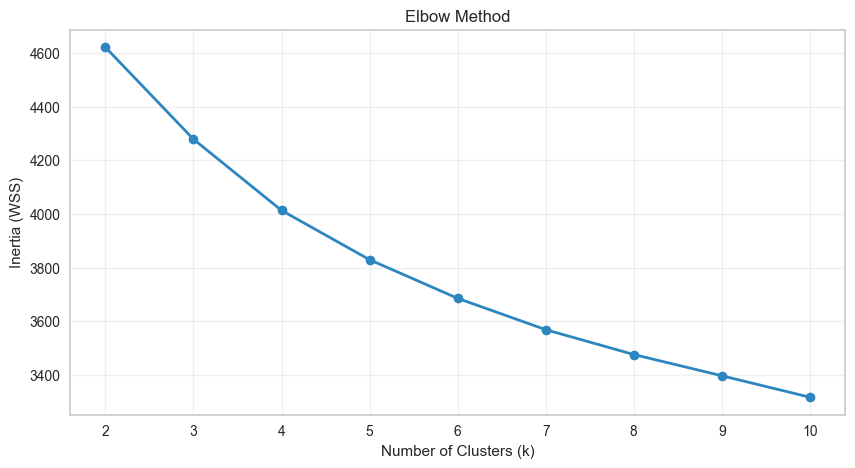

,k,WSS (Inertia),Silhouette Score,Reduction (%)
0,2,4621.083874,0.1781,nan%
1,3,4278.288867,0.1278,7.42%
2,4,4012.947615,0.1061,6.20%
3,5,3829.141183,0.1029,4.58%


In [65]:
# Setup
k_range = range(2, 11)
inertia = []
sil_scores = []

# Combined Logic Loop
for k in k_range:
    model = KMeans(
        n_clusters=k,
        n_init=50,
        init='k-means++',
        random_state=42).fit(clustering_data)
    
    inertia.append(model.inertia_)
    sil_scores.append(silhouette_score(clustering_data, model.labels_))

# Plotting the Elbow Method (Inertia)
plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker='o', linestyle='-', color='#2E86C1', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WSS)')
plt.title('Elbow Method')
plt.grid(True, alpha=0.3)
plt.show()

# Creating and Displaying the Styled Table
df_metrics = pd.DataFrame({
    'k': k_range,
    'WSS (Inertia)': inertia,
    'Silhouette Score': sil_scores
})

# Calculate the reduction percentage for the tie-breaker
df_metrics['Reduction (%)'] = df_metrics['WSS (Inertia)'].pct_change().abs() * 100

# Slice the dataframe to the first 5 rows
display(df_metrics.head(4).style.background_gradient(subset=['Silhouette Score'], cmap='YlGn')
                  .format({'Reduction (%)': "{:.2f}%", 'Silhouette Score': "{:.4f}"})
                  .highlight_max(subset=['Silhouette Score'], color='lightgreen'))

As shown in the figure, the Elbow curve exhibits a smooth and gradual decrease in clustering cost as the number of clusters increases, without a distinct point of sharp change in slope. Instead of forming a clear “elbow,” the curve follows a consistent downward trend, indicating that each additional cluster incrementally improves the model without a well-defined point of diminishing returns. This behavior suggests that the data does not contain well-separated groups, but rather exhibits continuous variation between observations and it is expected in medical datasets, where patient characteristics such as age, blood pressure, and heart rate tend to vary gradually rather than forming sharply distinct categories. Nevertheless, a slight flattening of the curve can be observed between k = 3 and k = 4, indicating that both values are plausible candidates.


Furthermore The Silhouette Score was evaluated, Although k = 2 achieved the highest silhouette score, it results in overly coarse and wide clustering with only two groups, which limits the depth of insights that can be derived. Increasing to k = 4 provides only a marginal improvement in WSS while noticeably reducing cluster quality, as indicated by the lower silhouette score. In contrast, k = 3 offers a balanced solution, maintaining a reasonably high silhouette score particularly acceptable given the complexity and variability inherent in medical datasets while achieving a meaningful reduction in WSS. This choice enables more informative and interpretable segmentation compared to k = 2, without the diminishing returns observed at k = 4.

### 3.4 Applying clustering and assigning cluster labels


In [45]:
# Create a copy of the dataset
patient_data = clustering_data.copy()

# Set optimal number of clusters
k_optimal = 3

# Initialize the model
kmeans_final = KMeans(
    n_clusters=k_optimal,
    random_state=42,
    init='k-means++',
    n_init=50
)

# Fit the model and predict cluster labels
clusters = kmeans_final.fit_predict(clustering_data)

# Assign cluster labels to the copied dataset
patient_data['cluster'] = clusters

## Section 4. Evaluate Cluster Quality

**WCSS (Within-Cluster Sum of Squares)**


**The Silhouette Score**


**Davies-Bouldin Index**

In [22]:
# Using our final model labels
labels = clusters

# Compute metrics
silhouette = silhouette_score(clustering_data, labels)
db_index = davies_bouldin_score(clustering_data, labels)
wcss = kmeans_final.inertia_

# Create a single-row table
evaluation_df = pd.DataFrame([{
    'k': 3,
    'Silhouette Score': f"{silhouette:.3f}",
    'Davies-Bouldin Index': f"{db_index:.3f}",
    'WCSS': f"{wcss:.3f}"
}])

# Save to CSV
evaluation_df.to_csv('Unsupervised_Learning/k-means_evaluation.csv', index=False)

# Display
evaluation_df

,k,Silhouette Score,Davies-Bouldin Index,WCSS
0,3,0.128,2.342,4278.289


**The Silhouette Score**, being close to zero, indicates that the clusters are not well separated and that there is considerable overlap between neighboring data points. While this is typically interpreted as poor clustering performance, it is important to contextualize this result within the domain of medical data. In such datasets, patient characteristics often exist along continuous spectra rather than forming clearly distinct groups, meaning that strict cluster boundaries are rarely present. Therefore, some degree of overlap is expected and does not necessarily invalidate the usefulness of the clustering. Despite the low silhouette score, the resulting clusters can still provide practical value. Rather than representing sharply defined categories, they can be interpreted as grouping patients with broadly similar risk profiles or clinical patterns. This makes the clustering useful for exploratory analysis and subgroup identification, even if it is not suitable for definitive classification or diagnosis.

**The Davies–Bouldin Index** of 2.342 further supports the observation of weak clustering quality. A higher value indicates that clusters are less compact and less well separated from each other, suggesting that intra-cluster similarity is relatively low compared to inter-cluster similarity. This implies that many patients lie near the boundaries of their assigned clusters while still sharing similarities with patients in neighboring clusters. Such behavior is reasonable in the context of medical data, where patient conditions and risk factors often overlap and evolve along continuous spectra, This behavior is consistent with real-world healthcare data, where heterogeneity and gradual transitions between patient states limit the formation of well-separated clusters. 

**The Within-Cluster Sum of Squares** (WCSS) value of 4278.289 represents the total variance within the clusters, indicating how closely data points are grouped around their respective cluster centroids. Lower WCSS values generally correspond to more compact clusters

Medical datasets frequently exhibit low silhouette scores due to overlapping patient characteristics and continuous variation in clinical features. This behavior has been widely observed in the literature, where clustering is used to identify patient subgroups or phenotypes rather than strictly separable classes. For example, studies such as Ahlqvist et al. (2018) on diabetes subtypes and Seymour et al. (2019) on sepsis phenotyping demonstrate that clinically meaningful clusters can still be identified despite overlap and weak separation. These findings reinforce that, in medical contexts, clustering results should be interpreted as approximate groupings that support risk stratification and exploratory analysis rather than definitive classifications.

> Ahlqvist, E., Storm, P., Käräjämäki, A., et al. (2018).  
   *Novel subgroups of adult-onset diabetes and their association with outcomes: a data-driven cluster analysis.*  
   The Lancet Diabetes & Endocrinology, 6(5), 361–369.  
   https://doi.org/10.1016/S2213-8587(18)30051-2  
>
> Seymour, C. W., Kennedy, J. N., Wang, S., et al. (2019).  
   *Derivation, validation, and potential treatment implications of novel clinical phenotypes for sepsis.*  
   JAMA, 321(20), 2003–2017.  
   https://doi.org/10.1001/jama.2019.5791  
>
> Shah, S. J., Katz, D. H., Selvaraj, S., et al. (2015).  
   *Phenomapping for novel classification of heart failure with preserved ejection fraction.*  
   Circulation, 131(3), 269–279.  
   https://doi.org/10.1161/CIRCULATIONAHA.114.010637  

## Section 5. Clusters Visualization


Most datasets contain many variables resulting in large dimensional space, making it impossible to see how points relate to one another in their raw state. By reducing the complexity of the data while preserving as much of the original variance in the structure as possible. This helps us verify that the clusters are distinct and provides a visual sanity check for the results of the clustering algorithm.

### **5.1 Principal Component Analysis (PCA)**
PCA follows a specific linear transformation process:

It aims to maximize the variance where it ensures that you squeeze the data into a 2D or 3D view while losing as little information as possible. Bt Projecting data onto a lower-dimensional subspace and identifying the principal components (the directions where the data is most spread out).

these directions are found by calculating the eigenvectors and eigenvalues of the covariance matrix:
Eigenvectors act as the possible "angles" or directions to view the data. Eigenvalues act as a score, telling us which "angle" shows the most spread. The eigenvectors with the largest eigenvalues are selected as the principal components. By using these as our axes (e.g., X and Y), we effectively capture the most significant patterns in the data.

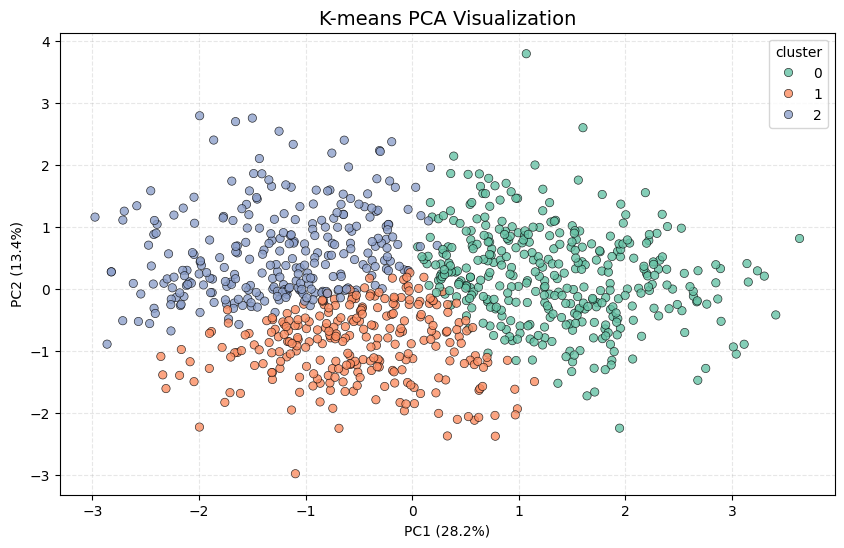

In [32]:
# Initialize PCA
pca = PCA(n_components=2, random_state=42)

# Transform the data
pca_components = pca.fit_transform(clustering_data)

# Save results to a dataframe for plotting
patient_data['pca_1'] = pca_components[:, 0]
patient_data['pca_2'] = pca_components[:, 1]

# Get the Variance Scores
# This tells us how much information we kept in our 2D view
var_info = pca.explained_variance_ratio_

# Plotting
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='pca_1', 
    y='pca_2', 
    hue='cluster', 
    data=patient_data, 
    palette='Set2', 
    edgecolor='black',
    alpha=0.8
)

plt.title('K-means PCA Visualization', fontsize=14)
plt.xlabel(f'PC1 ({var_info[0]:.1%})')
plt.ylabel(f'PC2 ({var_info[1]:.1%})')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

--

### **5.2 T-distributed Stochastic Neighbor Embeddin (t-SNE)** 


t-SNE is a non-linear dimensionality reduction technique designed to capture the local structure of data by preserving pairwise distances between points. It achieves this by converting the pairwise Euclidean distances between high-dimensional data points into joint probabilities and then
 t-SNE is stochastic (different results per run, requires fixing a seed)
minimizing the Kullback-Leibler divergence between these joint probabilities in both the high-dimensional and low-dimensional spaces. 

MUST ADD THE LIMITAION ON IT AND WAY OF HOW IT WORKS

This process helps to maintain the local relationships and clusters within the data, providing a more nuanced view of complex, non-linear structures.

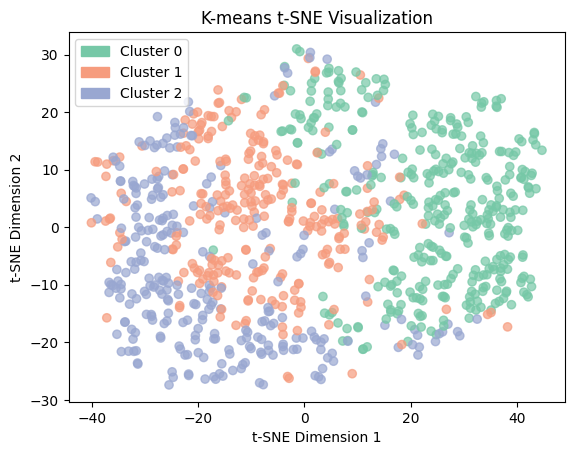

In [ ]:
tsne = TSNE(
    n_components=2,          # Better for binary-heavy data visualization
    perplexity=30,           # Balanced for ~900 samples
    learning_rate='auto',    # Keeps the optimization stable
    max_iter=1000,           
    random_state=42
)

X_tsne = tsne.fit_transform(clustering_data)

# Colors
color_map = {
    0: "#76c8a7",  # The green from your image
    1: "#f69c7e",  # The orange/coral
    2: "#99a7d1",  # The muted purple/blue
}

colors = [color_map[c] for c in clusters]

# Plot
plt.figure()
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, alpha=0.7)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("K-means t-SNE Visualization")

# Legend
handles = [
    mpatches.Patch(color=color_map[i], label=f'Cluster {i}')
    for i in range(3)
]

plt.legend(handles=handles)
plt.show()

--

### 5.3 Feature importance per cluster

Feature importance refers to the process of identifying and ranking the features that contribute the most to a model's decision-making process. In clustering, feature importance helps us understand which dimensions of the data are most influential in defining the clusters, even though there is no direct target variable as in supervised learning.

https://www.datasciencebase.com/unsupervised-ml/explainabliity-and-interpretablility/feature-importance-in-clustering/

(Unsupervised → Supervised)

To interpret the clusters generated by K-Means, an unsupervised-to-supervised approach was applied.  
Each cluster was treated as a binary classification problem (one-vs-rest), and a Random Forest model was trained to identify the most important features distinguishing each cluster.

Feature importance was computed using the Mean Decrease in Impurity (MDI), allowing us to understand which variables contribute most to the formation and separation of clusters.

This approach enhances the interpretability of clustering results, especially in medical datasets where understanding the drivers of group formation is critical.

In [52]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np


# X: original features (we REMOVE the cluster column because
# we want to explain it, not use it as input)
X = patient_data.drop(columns=['cluster'])

# y: cluster labels generated by KMeans
y = patient_data['cluster']


# Define parameters
# Number of top features to display per cluster
top_n = 5

# Dictionary to store feature importance results for each cluster
cluster_importance = {}

# Compute feature importance per cluster
# Loop through each unique cluster
for cluster_id in np.unique(y):

    # One-vs-Rest strategy:
    # Create binary labels where:
    # 1 = current cluster
    # 0 = all other clusters
    y_binary = (y == cluster_id).astype(int)

    # Initialize Random Forest model
    # This model will learn how to distinguish this cluster
    rf = RandomForestClassifier(
        n_estimators=200,   # number of decision trees
        random_state=42     # ensures reproducibility
    )

    # Train the model
    rf.fit(X, y_binary)

    # Extract feature importance scores
    # Each value represents how much the feature contributed
    importance = pd.Series(rf.feature_importances_, index=X.columns)

    # Select top N most important features
    top_features = importance.sort_values(ascending=False).head(top_n)

    # Store results for later visualization
    cluster_importance[cluster_id] = top_features


Cluster 0 - Top Features
MaxHR             0.308682
Age               0.175657
ST_Slope_Up       0.111568
ExerciseAngina    0.083748
Oldpeak           0.071969
dtype: float64


<Axes: title={'center': 'Cluster 0 Feature Importance'}>

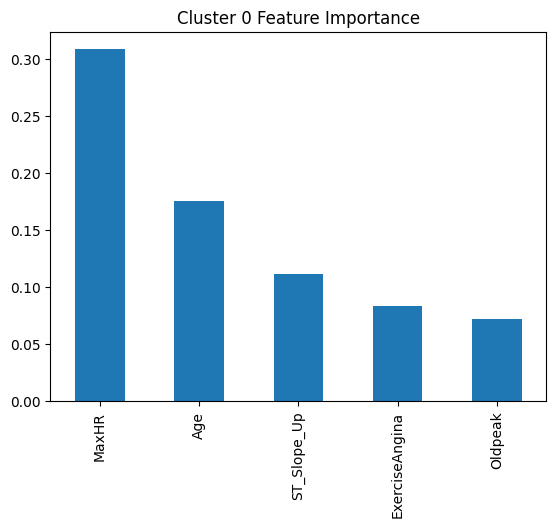

In [ ]:
# Cluster 0 Interpretation
cluster_id = 0

# Retrieve top features for this cluster
top_features = cluster_importance[cluster_id]

# Display results
print(f"Cluster {cluster_id} - Top Features")
print(top_features)

# Insight:
# These features represent the most important variables
# that distinguish Cluster 0 from the rest of the data.
# Higher importance means stronger influence on cluster formation.

# Plot feature importance
top_features.plot(kind='bar', title=f'Cluster {cluster_id} Feature Importance')



Cluster 1 - Top Features
RestingBP                  0.260564
MaxHR                      0.256518
Age                        0.120860
Oldpeak                    0.069083
Chol_category_Desirable    0.038434
dtype: float64


<Axes: title={'center': 'Cluster 1 Feature Importance'}>

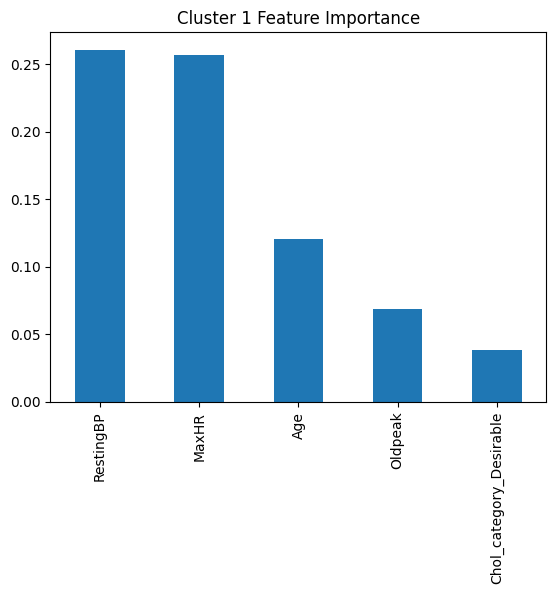

In [50]:
# Cluster 1 Interpretation

cluster_id = 1

top_features = cluster_importance[cluster_id]

print(f"Cluster {cluster_id} - Top Features")
print(top_features)

# Insight:
# These features explain what makes Cluster 1 unique
# compared to other clusters in the dataset.

top_features.plot(kind='bar', title=f'Cluster {cluster_id} Feature Importance')

Cluster 2 - Top Features
RestingBP      0.341038
Age            0.221476
Oldpeak        0.101073
MaxHR          0.097024
ST_Slope_Up    0.041124
dtype: float64


<Axes: title={'center': 'Cluster 2 Feature Importance'}>

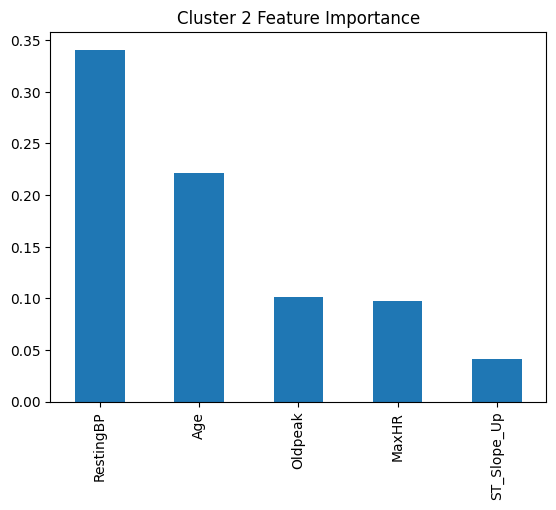

In [51]:
# Cluster 2 Interpretation

cluster_id = 2

top_features = cluster_importance[cluster_id]

print(f"Cluster {cluster_id} - Top Features")
print(top_features)

# Insight:
# These variables are the strongest drivers behind
# the formation of Cluster 2.

top_features.plot(kind='bar', title=f'Cluster {cluster_id} Feature Importance')

### 5.4 Cluster size distribution

---

# **HDBSCAN**

## Section 1. Clustering Rationale & Algorithm Selection

### **What is HDBSCAN Algorithm?**

HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise) is a clustering algorithm that builds a hierarchy of clusters based on density. It is an extension of the DBSCAN method, which is a density-based clustering method. However, DBSCAN struggles with the assumption of global density, meaning it uses the same density threshold for all clusters. This often does not comply with medical datasets or many real world datasets in general , where clusters may have varying densities and sizes. Unlike DBSCAN, HDBSCAN can identify these variations effectively.

One of the most interesting features of the HDBSCAN algorithm is its ability to decide the optimal number of clusters while remaining robust to noise and outliers. These outliers are prevalent in our medical dataset and cannot be ignored, as they may represent significant clinical cases. This process of selecting the appropriate number of clusters is handled systematically by examining cluster stability across various density thresholds.


### **How does it work?**

The HDBSCAN algorithm consist of two phases:

- ***Mutual Reachability Graph***\
The algorithm starts by computing the core distance $d_c$ for all points. This represents the distance between a point $x_p$ and its $n$-th nearest neighbor $x_{s}, where $n$ is defined by the `min_samples` parameter. The smaller core distance the more points near to it the more density spot the point in. It calculated by the following formula:  $$d_c(x_p) = d(x_p, x_s)$$\
Then it calculates the mutual reachability distance $d_m$ between every pair points using the following formula: $$d_m(x_p, x_q) = \max \{d_c(x_p), d_c(x_q), d(x_p, x_q)\}$$ By taking the maximum, the algorithm effectively spreads out points that are in sparse regions.Thus, even if two points are close to each other. if one of them is in a low-density spot (large $d_c$), the mutual reachability distance between them will be larger. This gives a small distance between points that are both close to each other and located in high-density regions.\
After the computing mutual reachability distances, the algorithm builds the mutual reachability graph $G_{ms}$, where each data point represented as a vertex, and the edges between points represent the mutual reachability distance between them.

- ***Hierarchical Clustering***\
As we mentioned before, the HDBSCAN finds the appropriate number of clusters by examining clusters stability across various density thresholds **$\epsilon$**. This gives all connected parts for all **$\epsilon$** values. This done as the following:
1. Extracting a minimum spanning tree (MST) of $G_{ms}$, that is the subset of edges that connects all vertices together, without any cycles, and with the minimum possible total edge weight.
2. Adding a "self edge" for each vertex on the MST with a weight equals to its core distance.
3. Create a single cluster that contains the whole MST.
4. Finding the edges with the greatest weight (core distance) and remove them to splits the vertex groups connected with a weak edge, generating two **connected components**.
5. Labeling the connected components (clusters).
    1. If a connected component contains only one vertex (no edge) or less than `min_cluster_size` parameter if specified, label it as null (noise).
    2. If a connected component contains more than one vertex label it as a new cluster.
6. Repeat 4-5 until there are no more connected components (clusters become stable).

### **Why is HDBSCAN suitable for our data?**

#### i. Dataset size & feature types

The HDBSCAN algorithm affected by high-dimensional spaces (50-100 features) and can result in curse of dimensionality unless dimensionality reduction techniques applied [-], however our dataset were shrink after performing multiple experiments by researchers to includes only the top 20 important features as their consequences (other illnesses) affects the heart disease [-]. Consequently, dimensionality is not a concern, as 20 features does not considered high-dimensional and as our sample size ($N = 917$) exceeds the recommended 10–20 times the number of features.

It is also capable of handling mixed data types including both continuos and categorical features as long as the categorical features are appropriately preprocessed (e.g., One-Hot Encoding for nominal data and Label Encoding for ordinal data). Our preprocessing pipeline has already addressed these requirements, making HDBSCAN suited for our dataset.

The HDBSCAN algorithm considered a good choice for complex datasets like our medical dataset, as it is able to handle sparse clusters with varying shapes and densities of patients. These variations results from the various combinations of features that leads to herat disease and other diseases that can result from those combinations and cause a heart disease, some of those caused combinations have a high density ( combinations associated with high occurrence heart disease cause like Diabetes) others can have low density ( unpopular heart disease causes and conditions), the HDBSCAN can handle this density variation problem and not only specify a single density threshold.

---

#### ii. Expected cluster shapes

---

#### iii. Scalability & interpretability

- **Scalability** \
In the theoretical explanation of HDBSCAN algorithm, the process of finding the nth-nearest neighbor (used to computed the core distance) is expensive with a time complexity of O($n_2$), since it compute the distances between all pairs of points. However, the implementation can be optimize to approximately O(n log n) using KD-trees for low-dimensional data (less than 20). As the dimensionality increases, the efficiency of KD-trees degrades due to the Curse of Dimensionality, and alternatives such as Ball Trees are used, although performance still worsens with higher dimensions. \
\
 Another theoretical complexity is building a graph that contains all edges ( based on mutual reachability distances), it take O($n_2$) as every vertex should be connected to every other vertexes. To optimize this, the algorithm use MST tree (Minimum Spanning Tree ) that contains the minimum set of edges that dropping any edge results in disconnected components (no cycles), and this set of edges should contains the minimum total wights. \
 \
  To further improve efficiency, the MST is not built over the full graph, but instead it built over a k-nearest neighbor graph, significantly reducing the number of edges. Additionally, the implementation uses Borůvka's algorithm (or its optimized variants), which has a time complexity of approximately O(|E| log |V|) in the worst case, where |E| is the number of edges and |V| is the number of vertices. \
  \
  This gives an approximately total time complexity O(n log n) for low-dimensional data which our dataset is around, but it can degrade toward O($n_2$) in high-dimensional spaces.

- **Interpretability**  \
The Interpretability in clustering algorithms defined by the ability to understanding the structure of clusters and their formation. The HDBSCAN algorithm produces a hierarchical structure and identifies noise. This hierarchical organization can facilitate interpretation by allowing users to explore clusters at different levels of granularity. However, it does not provide simple representations such as centroids. \
\
The hierarchical structure of clusters and noise identification is important for our dataset, as it helps in associating different types of patients within a hierarchical framework, which gives a valuable insights into relationships between patient groups at multiple levels, while also identifying outliers that may represent important or unusual medical cases.